# Installation de pandas 

In [ ]:
%pip install pandas

# Importation de libraries

In [1]:
## import raw data
import pandas as pd
import numpy as np

# Nettoyage de données

In [2]:
raw_data = pd.read_csv("../data/raw/flight_data_2024_sample.csv")

### Aperçu rapide

In [3]:
raw_data.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,4,18,4,2024-04-18,MQ,3535.0,DFW,"Dallas/Fort Worth, TX",Texas,...,0,151.0,144.0,119.0,835.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,AA,148.0,CLT,"Charlotte, NC",North Carolina,...,0,286.0,273.0,253.0,1773.0,0,0,0,0,0
2,2024,12,12,4,2024-12-12,9E,5440.0,CHA,"Chattanooga, TN",Tennessee,...,0,59.0,50.0,29.0,106.0,0,0,0,0,0
3,2024,4,8,1,2024-04-08,WN,1971.0,OMA,"Omaha, NE",Nebraska,...,0,180.0,177.0,163.0,1099.0,0,0,0,0,0
4,2024,2,16,5,2024-02-16,WN,862.0,BWI,"Baltimore, MD",Maryland,...,0,90.0,96.0,76.0,399.0,0,0,0,0,0


# 1. Compréhension et exploration du dataset
 Avant de commencer le nettoyage des données, nous allons commencer par mieux comprendre les informations qu'elles contiennent.

In [4]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 10000 non-null  int64  
 1   month                10000 non-null  int64  
 2   day_of_month         10000 non-null  int64  
 3   day_of_week          10000 non-null  int64  
 4   fl_date              10000 non-null  object 
 5   op_unique_carrier    10000 non-null  object 
 6   op_carrier_fl_num    10000 non-null  float64
 7   origin               10000 non-null  object 
 8   origin_city_name     10000 non-null  object 
 9   origin_state_nm      10000 non-null  object 
 10  dest                 10000 non-null  object 
 11  dest_city_name       10000 non-null  object 
 12  dest_state_nm        10000 non-null  object 
 13  crs_dep_time         10000 non-null  int64  
 14  dep_time             9884 non-null   float64
 15  dep_delay            9884 non-null   

In [5]:
raw_data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
year,10000.0,NaN,NaN,NaN,2024.0,0.0,2024.0,2024.0,2024.0,2024.0,2024.0
month,10000.0,NaN,NaN,NaN,6.6132,3.377858,1.0,4.0,7.0,10.0,12.0
day_of_month,10000.0,NaN,NaN,NaN,15.843,8.792774,1.0,8.0,16.0,23.0,31.0
day_of_week,10000.0,NaN,NaN,NaN,3.9502,2.00637,1.0,2.0,4.0,6.0,7.0
fl_date,10000,366,2024-08-09,47,NaN,NaN,NaN,NaN,NaN,NaN,NaN
op_unique_carrier,10000,15,WN,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN
op_carrier_fl_num,10000.0,NaN,NaN,NaN,2529.7626,1655.998442,1.0,1172.0,2254.0,3742.0,8771.0
origin,10000,284,ATL,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
origin_city_name,10000,278,"Chicago, IL",516,NaN,NaN,NaN,NaN,NaN,NaN,NaN
origin_state_nm,10000,52,California,1068,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
raw_data.shape

(10000, 35)

In [7]:
raw_data.columns

Index(['year', 'month', 'day_of_month', 'day_of_week', 'fl_date',
       'op_unique_carrier', 'op_carrier_fl_num', 'origin', 'origin_city_name',
       'origin_state_nm', 'dest', 'dest_city_name', 'dest_state_nm',
       'crs_dep_time', 'dep_time', 'dep_delay', 'taxi_out', 'wheels_off',
       'wheels_on', 'taxi_in', 'crs_arr_time', 'arr_time', 'arr_delay',
       'cancelled', 'cancellation_code', 'diverted', 'crs_elapsed_time',
       'actual_elapsed_time', 'air_time', 'distance', 'carrier_delay',
       'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay'],
      dtype='object')

In [8]:
# 1️⃣ Convert date column
raw_data['fl_date'] = pd.to_datetime(raw_data['fl_date'], errors='coerce')
# 2️⃣ Ensure numeric columns are numeric (even if they contain NaN or wrong chars)
numeric_cols = [
    'year', 'month', 'day_of_month', 'day_of_week',
    'op_carrier_fl_num', 'crs_dep_time', 'dep_time', 'dep_delay',
    'taxi_out', 'wheels_off', 'wheels_on', 'taxi_in', 'crs_arr_time',
    'arr_time', 'arr_delay', 'cancelled', 'diverted', 'crs_elapsed_time',
    'actual_elapsed_time', 'air_time', 'distance',
    'carrier_delay', 'weather_delay', 'nas_delay',
    'security_delay', 'late_aircraft_delay'
]
raw_data[numeric_cols] = raw_data[numeric_cols].apply(pd.to_numeric, errors='coerce')
# 3️⃣ Convert categorical columns to 'category' type
cat_cols = [
    'op_unique_carrier', 'origin', 'origin_city_name', 'origin_state_nm',
    'dest', 'dest_city_name', 'dest_state_nm', 'cancellation_code'
]
for col in cat_cols:
    raw_data[col] = raw_data[col].astype('category')


# verify the conversion
raw_data.info() 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   year                 10000 non-null  int64         
 1   month                10000 non-null  int64         
 2   day_of_month         10000 non-null  int64         
 3   day_of_week          10000 non-null  int64         
 4   fl_date              10000 non-null  datetime64[ns]
 5   op_unique_carrier    10000 non-null  category      
 6   op_carrier_fl_num    10000 non-null  float64       
 7   origin               10000 non-null  category      
 8   origin_city_name     10000 non-null  category      
 9   origin_state_nm      10000 non-null  category      
 10  dest                 10000 non-null  category      
 11  dest_city_name       10000 non-null  category      
 12  dest_state_nm        10000 non-null  category      
 13  crs_dep_time         10000 non-n

In [9]:
time_cols = ['crs_dep_time', 'dep_time', 'wheels_off', 'wheels_on', 'crs_arr_time',
    'arr_time']
# Avant la modification du format 
raw_data[['crs_dep_time', 'dep_time', 'wheels_off', 'wheels_on', 'crs_arr_time',
    'arr_time']].head()

,crs_dep_time,dep_time,wheels_off,wheels_on,crs_arr_time,arr_time
0,1018,1015.0,1036.0,1135.0,1149,1139.0
1,1637,1633.0,1647.0,1900.0,1923,1906.0
2,1000,952.0,1005.0,1034.0,1059,1042.0
3,1330,1334.0,1342.0,1425.0,1430,1431.0
4,1340,1333.0,1349.0,1505.0,1510,1509.0


In [10]:

# Fonction pour convertir HHMM → hh:mm
def hhmm_format(hhmm):
    try:
        hhmm = int(hhmm)          # s'assure que c'est un entier
        hours = hhmm // 100
        mins = hhmm % 100
        return f"{hours:02d}:{mins:02d}"
    except:
        return None  # gère les valeurs manquantes ou incorrectes

# Appliquer la conversion à toutes les colonnes de temps
for col in time_cols:
    raw_data[col + '_hhmm'] = raw_data[col].apply(hhmm_format)

# Vérifier le résultat
raw_data[['crs_dep_time_hhmm', 'dep_time_hhmm', 'wheels_off_hhmm', 'wheels_on_hhmm', 'crs_arr_time_hhmm',
    'arr_time_hhmm']].head()


,crs_dep_time_hhmm,dep_time_hhmm,wheels_off_hhmm,wheels_on_hhmm,crs_arr_time_hhmm,arr_time_hhmm
0,10:18,10:15,10:36,11:35,11:49,11:39
1,16:37,16:33,16:47,19:00,19:23,19:06
2,10:00,09:52,10:05,10:34,10:59,10:42
3,13:30,13:34,13:42,14:25,14:30,14:31
4,13:40,13:33,13:49,15:05,15:10,15:09


In [11]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 41 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   year                 10000 non-null  int64         
 1   month                10000 non-null  int64         
 2   day_of_month         10000 non-null  int64         
 3   day_of_week          10000 non-null  int64         
 4   fl_date              10000 non-null  datetime64[ns]
 5   op_unique_carrier    10000 non-null  category      
 6   op_carrier_fl_num    10000 non-null  float64       
 7   origin               10000 non-null  category      
 8   origin_city_name     10000 non-null  category      
 9   origin_state_nm      10000 non-null  category      
 10  dest                 10000 non-null  category      
 11  dest_city_name       10000 non-null  category      
 12  dest_state_nm        10000 non-null  category      
 13  crs_dep_time         10000 non-n

In [12]:
raw_data.drop(['crs_dep_time', 'dep_time', 'wheels_off', 'wheels_on', 'crs_arr_time',
    'arr_time'], axis=1, inplace=True)

In [13]:
raw_data.head()
raw_data.to_csv('modified_data.csv', index=False)

## 2. Nettoyage des données
# Traitement des valeurs manquantes
A partir de là, nous allons commencer le nettoyage de ces données, en commencant par détécter et traiter les valeurs manquantes.
On va supprimer les colonnes qui contiennent un nombre élevé de valeurs manquantes/nulles, comme la colonne 'cancellation_code'

In [14]:
raw_data.isnull().sum()

year                      0
month                     0
day_of_month              0
day_of_week               0
fl_date                   0
op_unique_carrier         0
op_carrier_fl_num         0
origin                    0
origin_city_name          0
origin_state_nm           0
dest                      0
dest_city_name            0
dest_state_nm             0
dep_delay               116
taxi_out                120
taxi_in                 127
arr_delay               164
cancelled                 0
cancellation_code      9878
diverted                  0
crs_elapsed_time          0
actual_elapsed_time     164
air_time                164
distance                  0
carrier_delay             0
weather_delay             0
nas_delay                 0
security_delay            0
late_aircraft_delay       0
crs_dep_time_hhmm         0
dep_time_hhmm           116
wheels_off_hhmm         120
wheels_on_hhmm          127
crs_arr_time_hhmm         0
arr_time_hhmm           127
dtype: int64

In [15]:
raw_data.drop('cancellation_code', axis=1, inplace=True)

In [16]:
raw_data.isnull().sum()

year                     0
month                    0
day_of_month             0
day_of_week              0
fl_date                  0
op_unique_carrier        0
op_carrier_fl_num        0
origin                   0
origin_city_name         0
origin_state_nm          0
dest                     0
dest_city_name           0
dest_state_nm            0
dep_delay              116
taxi_out               120
taxi_in                127
arr_delay              164
cancelled                0
diverted                 0
crs_elapsed_time         0
actual_elapsed_time    164
air_time               164
distance                 0
carrier_delay            0
weather_delay            0
nas_delay                0
security_delay           0
late_aircraft_delay      0
crs_dep_time_hhmm        0
dep_time_hhmm          116
wheels_off_hhmm        120
wheels_on_hhmm         127
crs_arr_time_hhmm        0
arr_time_hhmm          127
dtype: int64

On va maintenant traiter les valeurs manquantes des variables numériques, en les remplaçant par leur médiane (plutôt que la moyenne) parce qu'elle est moins influencée par les valeurs extrêmes.
Dans ce cas les variables numériques sont: dep_delay, taxi_in, taxi_out, arr_delay, actual_elapsed_time, air_time

In [17]:
cols = ['dep_delay', 'taxi_in', 'taxi_out', 'arr_delay', 'actual_elapsed_time', 'air_time']
raw_data[cols] = raw_data[cols].fillna(raw_data[cols].median())

In [18]:
# Vérifier si les valeurs manquantes ont bien étés remplacées par les médianes
raw_data[cols].isnull().sum()

dep_delay              0
taxi_in                0
taxi_out               0
arr_delay              0
actual_elapsed_time    0
air_time               0
dtype: int64

Pour les valeurs temporelles, on va remplacer les valeurs manquantes par 'Unknown'

In [19]:
time = ['dep_time_hhmm', 'wheels_off_hhmm', 'wheels_on_hhmm', 'arr_time_hhmm']
raw_data[time] = raw_data[time].fillna('Unknown')

In [20]:
# Verifier si les valeurs temporelles manquantes ont bien été remplacées par 'Unknown'
raw_data[time].isnull().sum()

dep_time_hhmm      0
wheels_off_hhmm    0
wheels_on_hhmm     0
arr_time_hhmm      0
dtype: int64

# Gestion des doublons

In [ ]:
# Gérer les doublons
# On vérifie le nombre de doublons qu'il y a
raw_data.duplicated().sum()
# Aucun doublon n'a été trouvé

np.int64(0)

# Vérification de la cohérence et valeurs aberrantes

In [ ]:
%pip install matplotlib

In [25]:
import matplotlib.pyplot as plt

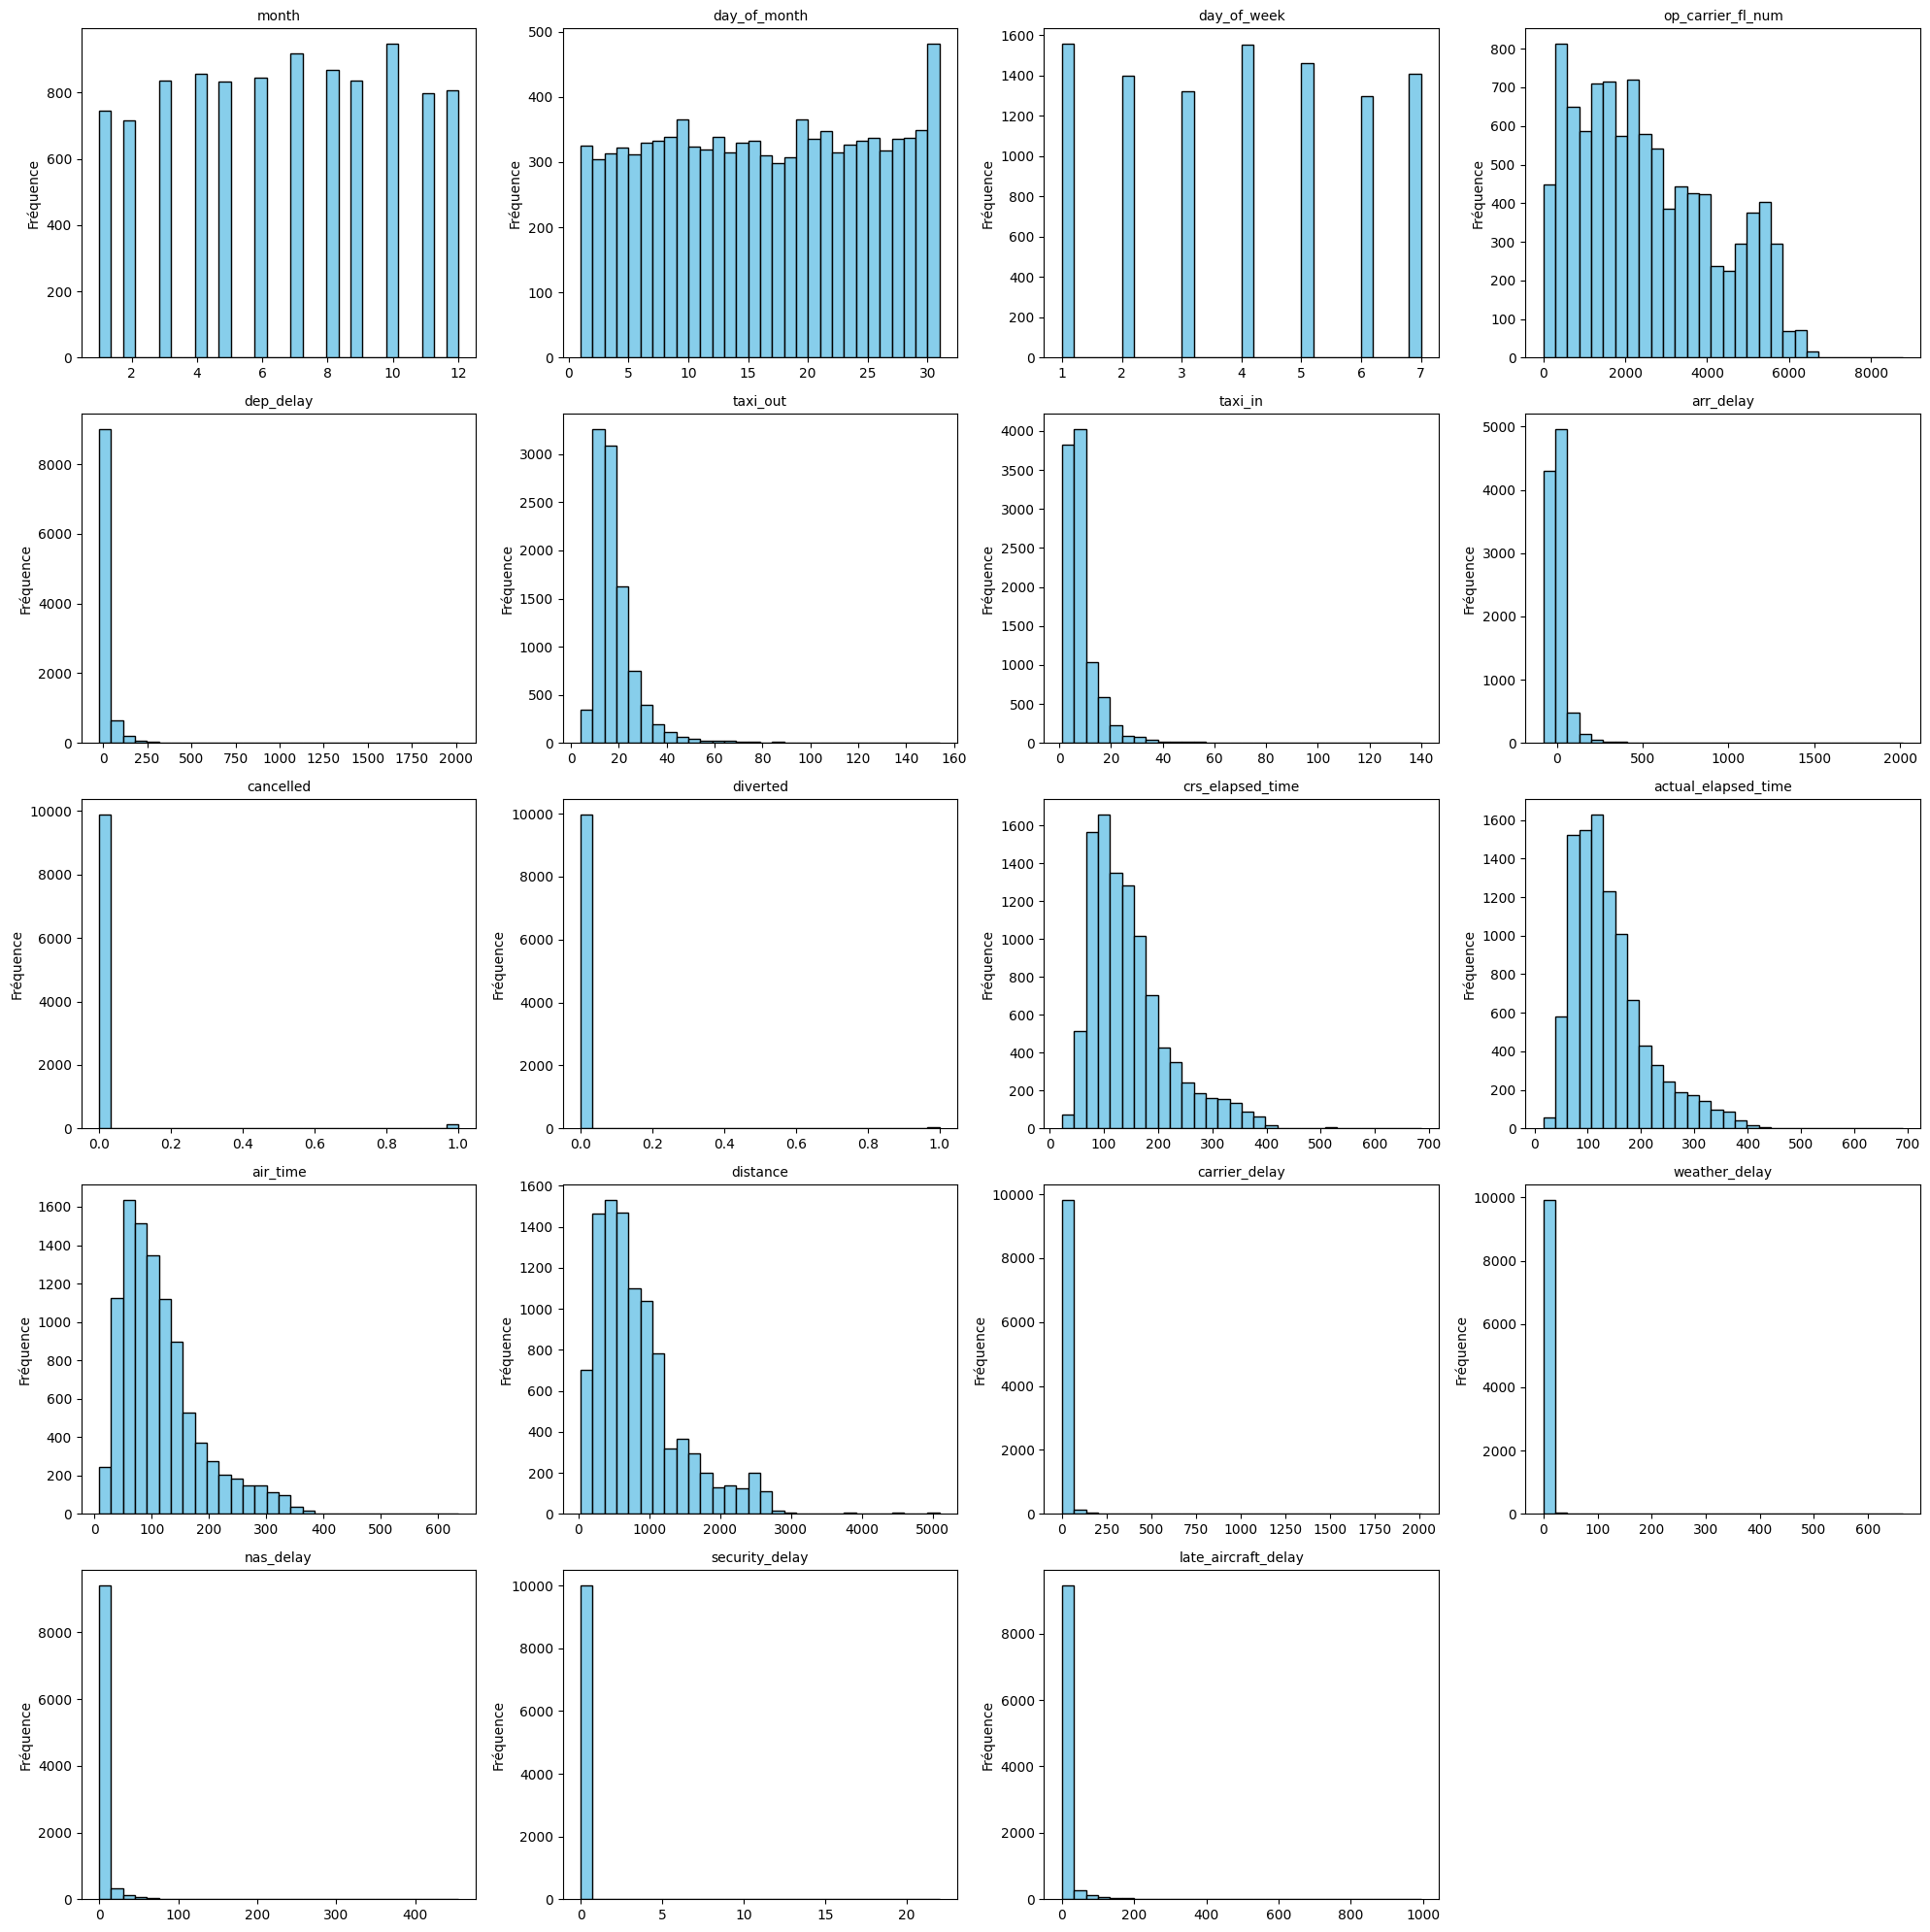

In [ ]:
# Visualisation des variables numériques en utilisant des histogrammes

# Liste des colonnes numériques
numeric_columns = ['month', 'day_of_month', 'day_of_week', 'op_carrier_fl_num', 'dep_delay', 'taxi_out',
            'taxi_in', 'arr_delay', 'cancelled', 'diverted', 'crs_elapsed_time', 'actual_elapsed_time', 'air_time',
            'distance', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']

plt.figure(figsize=(20, 20))


for i, col in enumerate(numeric_columns, 1):
    plt.subplot(5, 4, i)
    plt.hist(raw_data[col].dropna(), bins=30, color='skyblue', edgecolor='black')
    plt.title(col, fontsize=10)
    plt.xlabel('')
    plt.ylabel('Fréquence')

plt.tight_layout()
plt.show()

### Commentaire

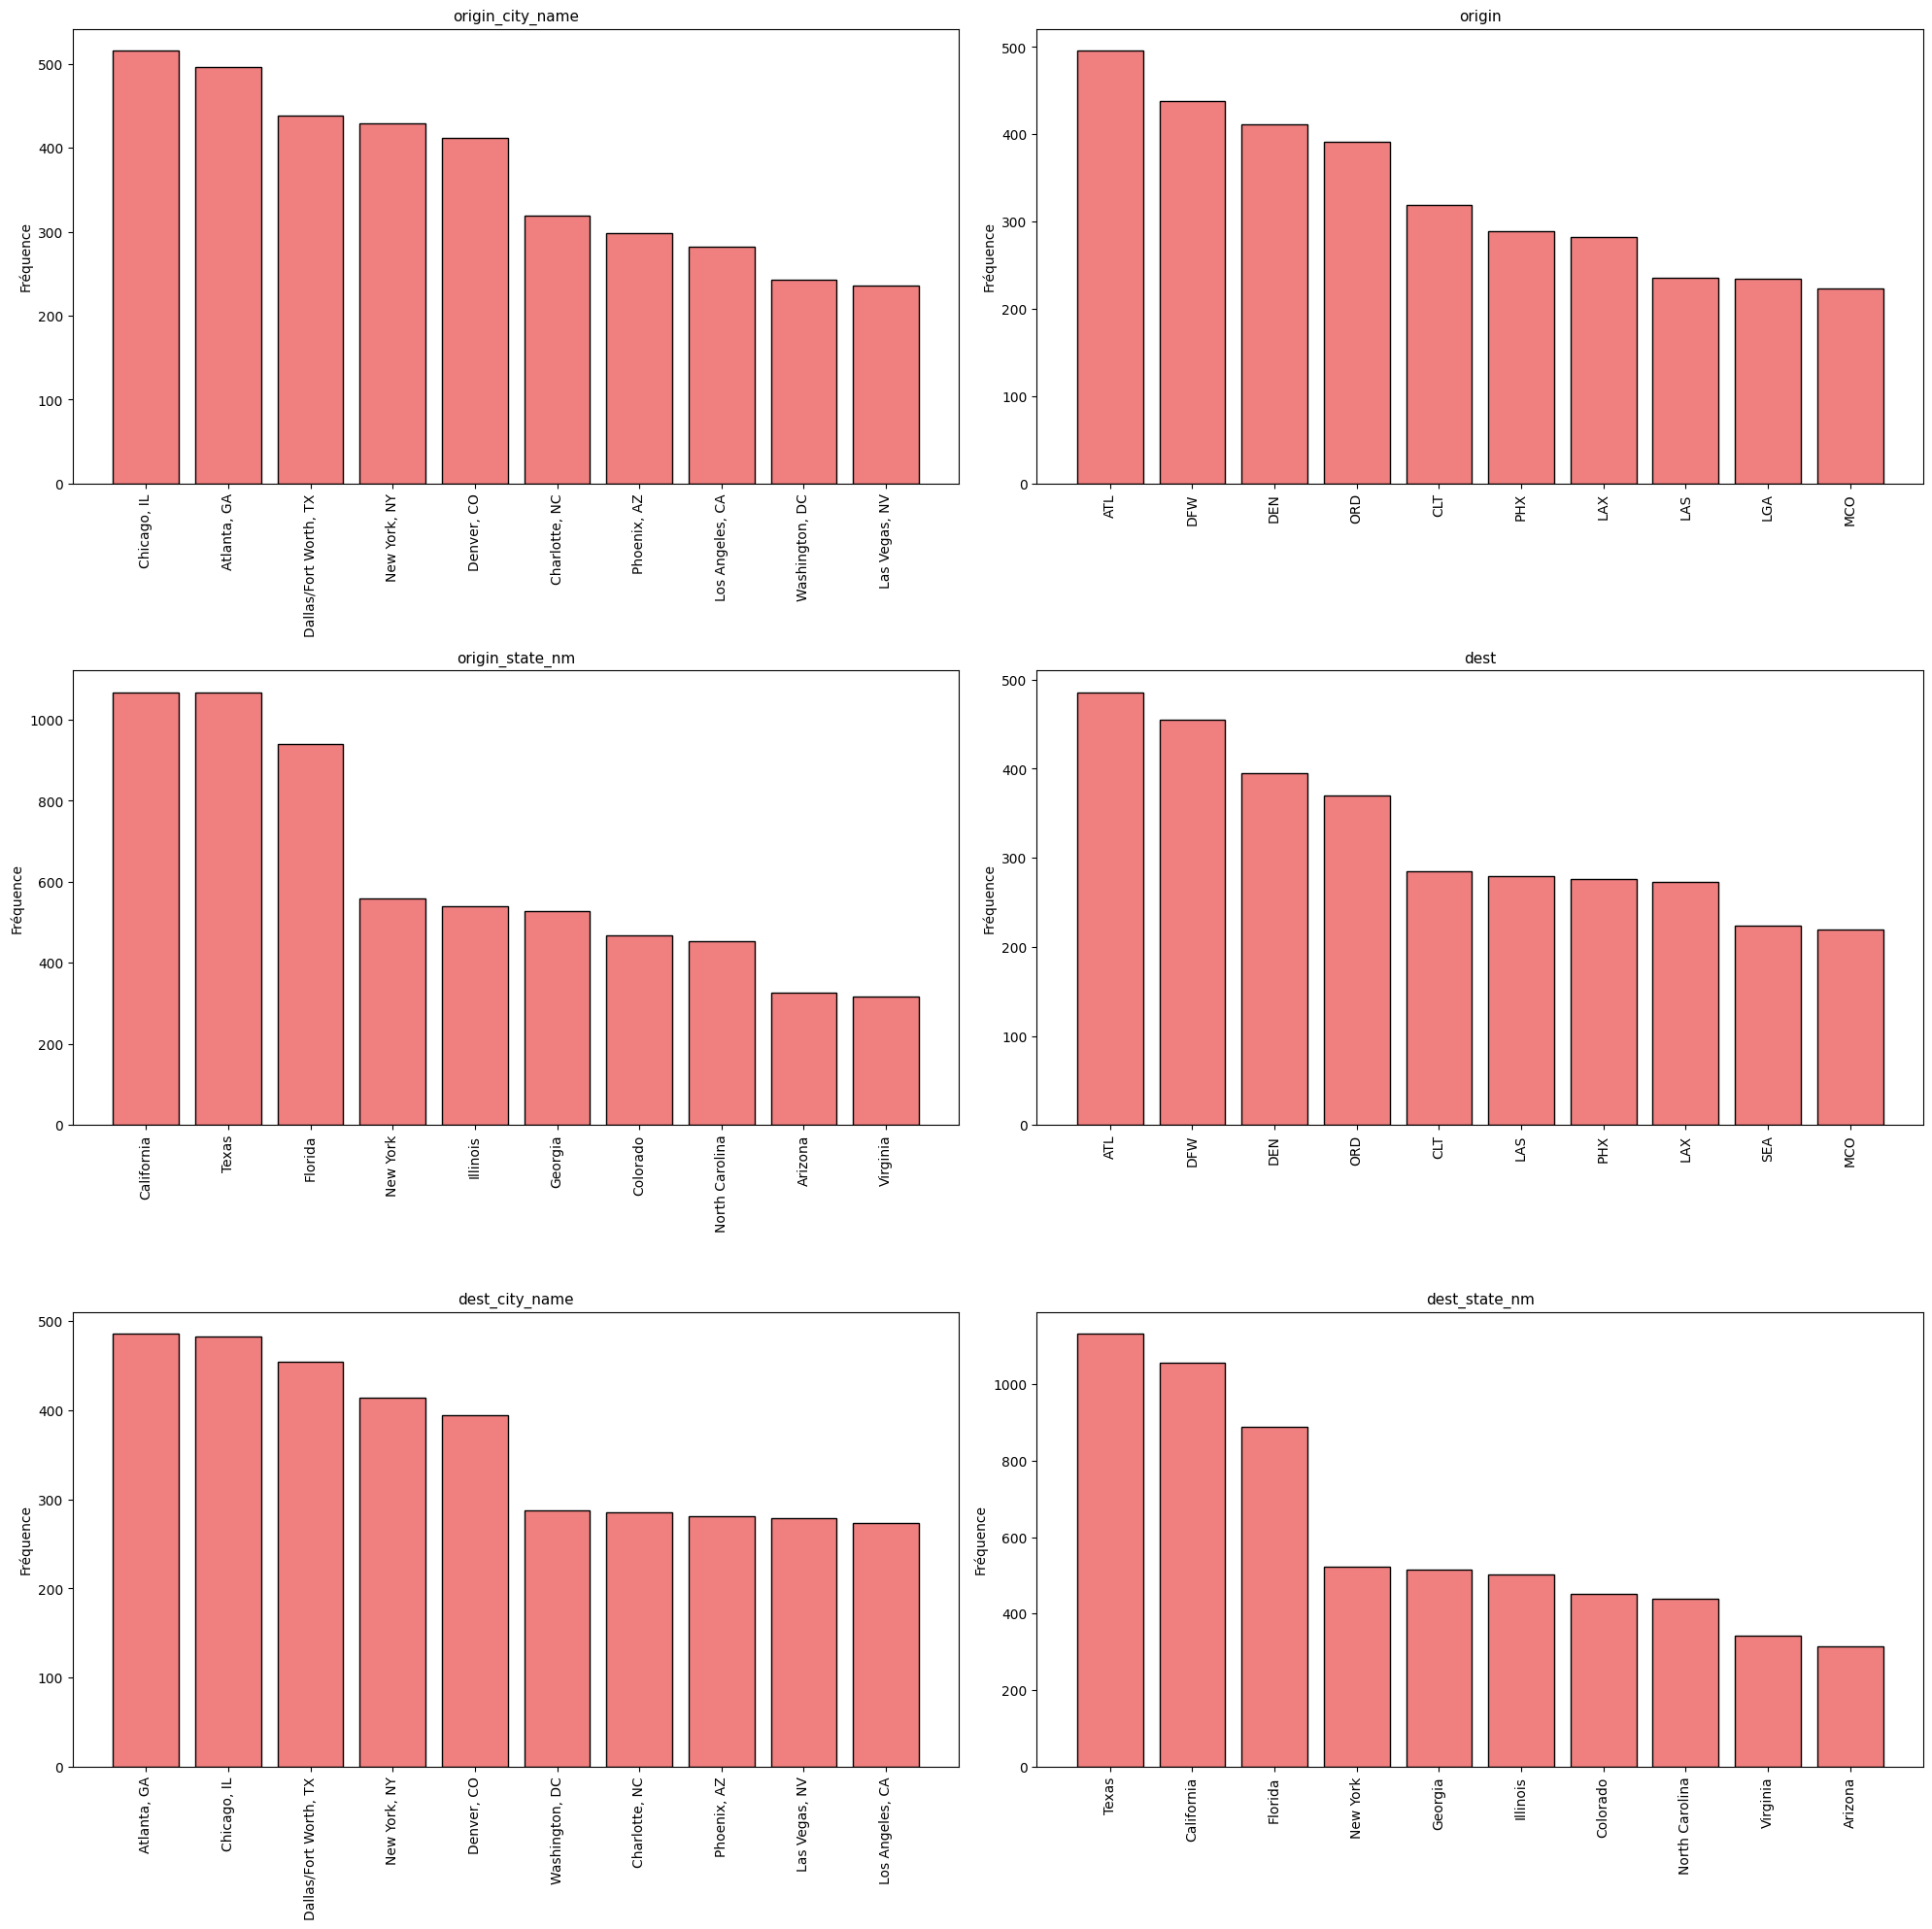

In [32]:
# Visualisation des données catégorielles avec des bar charts
categorical_columns =['origin_city_name','origin','origin_state_nm', 'dest', 'dest_city_name', 
                    'dest_state_nm']

# Taille globale de la figure
plt.figure(figsize=(20, 25))

for i, col in enumerate(categorical_columns, 1):
    plt.subplot(4, 2, i)  # 4 lignes × 2 colonnes = 8 graphiques
    value_counts = raw_data[col].value_counts().head(10)  # affiche les 10 catégories les + fréquentes
    plt.bar(value_counts.index.astype(str), value_counts.values, color='lightcoral', edgecolor='black')
    plt.title(col, fontsize=11)
    plt.xticks(rotation=90)
    plt.ylabel("Fréquence")

plt.tight_layout()
plt.show()



In [37]:
# Analyse des variables temporelles
time_columns = ['dep_time_hhmm', 'crs_dep_time_hhmm', 'wheels_off_hhmm', 'wheels_on_hhmm', 'arr_time_hhmm', 'crs_arr_time_hhmm']

for col in time_columns:
    raw_data[col] = pd.to_datetime(raw_data[col], format='%H:%M', errors='coerce').dt.time

raw_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   year                 10000 non-null  int64         
 1   month                10000 non-null  int64         
 2   day_of_month         10000 non-null  int64         
 3   day_of_week          10000 non-null  int64         
 4   fl_date              10000 non-null  datetime64[ns]
 5   op_unique_carrier    10000 non-null  category      
 6   op_carrier_fl_num    10000 non-null  float64       
 7   origin               10000 non-null  category      
 8   origin_city_name     10000 non-null  category      
 9   origin_state_nm      10000 non-null  category      
 10  dest                 10000 non-null  category      
 11  dest_city_name       10000 non-null  category      
 12  dest_state_nm        10000 non-null  category      
 13  dep_delay            10000 non-n

In [38]:
for col in time_columns:
    mask_invalid = pd.to_datetime(raw_data[col], format = "%H:%M", errors='coerce').isna()
    if mask_invalid.any():
        print(f"Valeurs aberrantes dans {col}: ")
        print(raw_data.loc[mask_invalid, col].unique())

Valeurs aberrantes dans dep_time_hhmm: 
<DatetimeArray>
['NaT']
Length: 1, dtype: datetime64[ns]
Valeurs aberrantes dans crs_dep_time_hhmm: 
<DatetimeArray>
['NaT']
Length: 1, dtype: datetime64[ns]
Valeurs aberrantes dans wheels_off_hhmm: 
<DatetimeArray>
['NaT']
Length: 1, dtype: datetime64[ns]
Valeurs aberrantes dans wheels_on_hhmm: 
<DatetimeArray>
['NaT']
Length: 1, dtype: datetime64[ns]
Valeurs aberrantes dans arr_time_hhmm: 
<DatetimeArray>
['NaT']
Length: 1, dtype: datetime64[ns]
Valeurs aberrantes dans crs_arr_time_hhmm: 
<DatetimeArray>
['NaT']
Length: 1, dtype: datetime64[ns]
